In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic Dataset
df = sns.load_dataset("titanic")

print("===== First 5 Rows =====")
print(df.head())

print("\n===== Last 5 Rows =====")
print(df.tail())

print("\n===== Random 5 Rows =====")
print(df.sample(5))

===== First 5 Rows =====
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

===== Last 5 Rows =====
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1  

In [ ]:
print("===== Dataset Shape =====")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\n===== Column Names =====")
print(df.columns.tolist())

print("\n===== Data Types =====")
print(df.dtypes)

print("\n===== Dataset Information =====")
df.info()

In [ ]:
print("===== Statistical Description (Numeric Columns) =====")
print(df.describe())

print("\n===== Statistical Description (All Columns) =====")
print(df.describe(include='all'))

===== Statistical Description (Numeric Columns) =====
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

===== Statistical Description (All Columns) =====
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2     

In [ ]:
print("===== Missing Values per Column =====")
print(df.isnull().sum())

print("\n===== Percentage of Missing Values =====")
print((df.isnull().sum() / len(df) * 100).round(2))

===== Missing Values per Column =====
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

===== Percentage of Missing Values =====
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


In [ ]:
print("===== Duplicate Rows =====")
print(df.duplicated().sum())

print("\n===== Unique Values in Each Column =====")
print(df.nunique())

print("\n===== Passenger Class Distribution =====")
print(df["pclass"].value_counts())

print("\n===== Gender Distribution =====")
print(df["sex"].value_counts())

print("\n===== Survival Distribution =====")
print(df["survived"].value_counts())
print("\nSurvival Rate (%):")
print((df["survived"].value_counts(normalize=True) * 100).round(2))

===== Duplicate Rows =====
107

===== Unique Values in Each Column =====
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

===== Passenger Class Distribution =====
pclass
3    491
1    216
2    184
Name: count, dtype: int64

===== Gender Distribution =====
sex
male      577
female    314
Name: count, dtype: int64

===== Survival Distribution =====
survived
0    549
1    342
Name: count, dtype: int64

Survival Rate (%):
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [ ]:
numeric_cols = ["age", "fare", "sibsp", "parch"]

for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"Feature: {col}")
    print(f"  Mean:   {mean_val:.4f}")
    print(f"  Median: {median_val:.4f}")
    print(f"  Mode:   {mode_val:.4f}")
    print("-" * 40)

Feature: age
  Mean:   29.6991
  Median: 28.0000
  Mode:   24.0000
----------------------------------------
Feature: fare
  Mean:   32.2042
  Median: 14.4542
  Mode:   8.0500
----------------------------------------
Feature: sibsp
  Mean:   0.5230
  Median: 0.0000
  Mode:   0.0000
----------------------------------------
Feature: parch
  Mean:   0.3816
  Median: 0.0000
  Mode:   0.0000
----------------------------------------


In [ ]:
for col in numeric_cols:
    variance = df[col].var()
    std_dev = df[col].std()
    data_range = df[col].max() - df[col].min()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    print(f"Feature: {col}")
    print(f"  Variance:           {variance:.4f}")
    print(f"  Std Deviation:      {std_dev:.4f}")
    print(f"  Range (Max - Min):  {data_range:.4f}")
    print(f"  IQR (Q3 - Q1):      {q3 - q1:.4f}")
    print("-" * 40)

Feature: age
  Variance:           211.0191
  Std Deviation:      14.5265
  Range (Max - Min):  79.5800
  IQR (Q3 - Q1):      17.8750
----------------------------------------
Feature: fare
  Variance:           2469.4368
  Std Deviation:      49.6934
  Range (Max - Min):  512.3292
  IQR (Q3 - Q1):      23.0896
----------------------------------------
Feature: sibsp
  Variance:           1.2160
  Std Deviation:      1.1027
  Range (Max - Min):  8.0000
  IQR (Q3 - Q1):      1.0000
----------------------------------------
Feature: parch
  Variance:           0.6497
  Std Deviation:      0.8061
  Range (Max - Min):  6.0000
  IQR (Q3 - Q1):      0.0000
----------------------------------------


In [ ]:
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"Feature: {col}")
    print(f"  Skewness (Asymmetry): {skewness:.4f}")
    print(f"  Kurtosis (Tails):     {kurtosis:.4f}")
    print("-" * 40)

Feature: age
  Skewness (Asymmetry): 0.3891
  Kurtosis (Tails):     0.1783
----------------------------------------
Feature: fare
  Skewness (Asymmetry): 4.7873
  Kurtosis (Tails):     33.3981
----------------------------------------
Feature: sibsp
  Skewness (Asymmetry): 3.6954
  Kurtosis (Tails):     17.8804
----------------------------------------
Feature: parch
  Skewness (Asymmetry): 2.7491
  Kurtosis (Tails):     9.7781
----------------------------------------


In [ ]:
grouped_survived = df.groupby("survived")

print("--- Group-Wise Mean Values (by Survival) ---")
print(grouped_survived[numeric_cols].mean())

print("\n--- Group-Wise Standard Deviation (by Survival) ---")
print(grouped_survived[numeric_cols].std())

aggregated_stats = df.groupby("pclass")["fare"].agg(["mean", "median", "std", "skew"])
print("\nAggregated Fare Statistics by Passenger Class:\n", aggregated_stats)

--- Group-Wise Mean Values (by Survival) ---
                age       fare     sibsp     parch
survived                                          
0         30.626179  22.117887  0.553734  0.329690
1         28.343690  48.395408  0.473684  0.464912

--- Group-Wise Standard Deviation (by Survival) ---
                age       fare     sibsp     parch
survived                                          
0         14.172110  31.388207  1.288399  0.823166
1         14.950952  66.596998  0.708688  0.771712

Aggregated Fare Statistics by Passenger Class:
              mean   median        std      skew
pclass                                         
1       84.154687  60.2875  78.380373  2.835045
2       20.662183  14.2500  13.417399  2.037780
3       13.675550   8.0500  11.778142  2.736072


In [ ]:
print("Survival Rate by Sex:")
print(df.groupby("sex")["survived"].mean().round(4))

print("\nSurvival Rate by Passenger Class:")
print(df.groupby("pclass")["survived"].mean().round(4))

print("\nSurvival Rate by Embarkation Port:")
print(df.groupby("embarked")["survived"].mean().round(4))

print("\nCross-tab: Class vs Sex Survival Counts")
print(pd.crosstab([df["pclass"], df["sex"]], df["survived"]))

Survival Rate by Sex:
sex
female    0.7420
male      0.1889
Name: survived, dtype: float64

Survival Rate by Passenger Class:
pclass
1    0.6296
2    0.4728
3    0.2424
Name: survived, dtype: float64

Survival Rate by Embarkation Port:
embarked
C    0.5536
Q    0.3896
S    0.3370
Name: survived, dtype: float64

Cross-tab: Class vs Sex Survival Counts
survived         0   1
pclass sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47


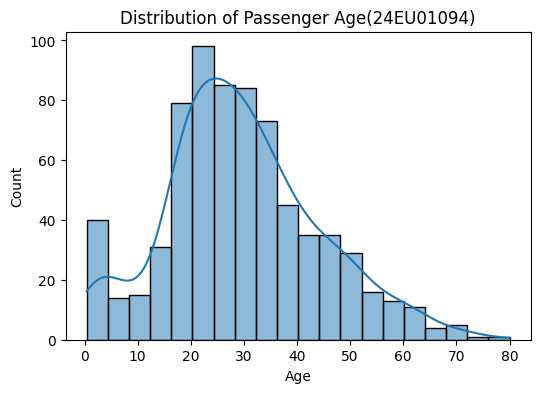

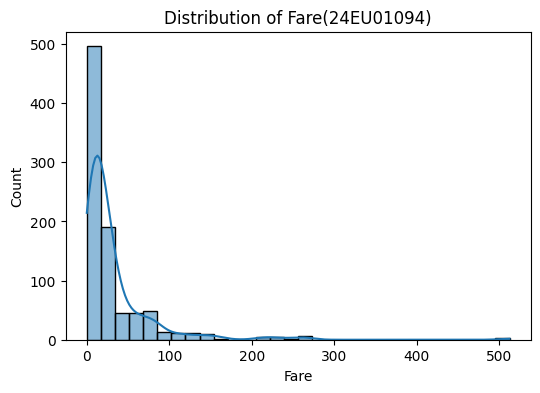

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"].dropna(), bins=20, kde=True)
plt.title("Distribution of Passenger Age(24EU01094)")
plt.xlabel("Age")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Distribution of Fare(24EU01094)")
plt.xlabel("Fare")
plt.show()

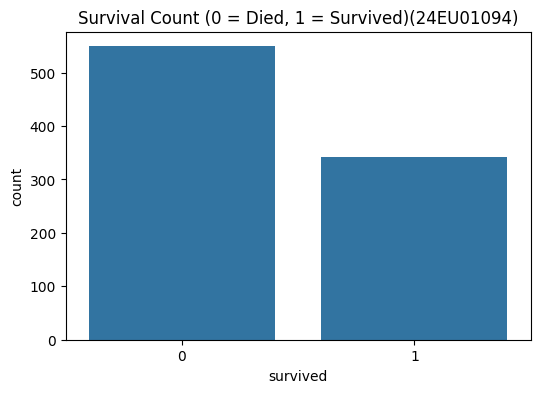

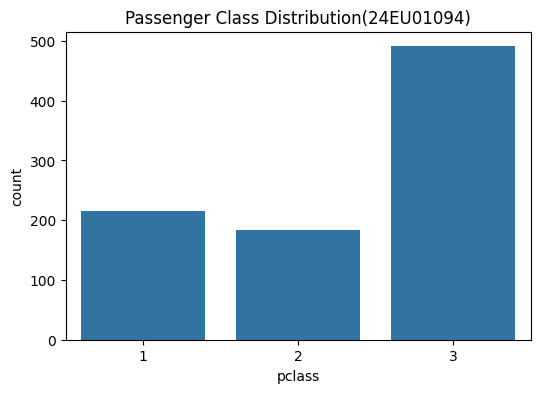

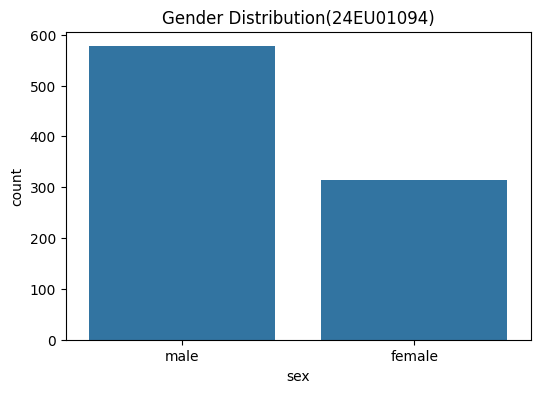

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="survived", data=df)
plt.title("Survival Count (0 = Died, 1 = Survived)(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="pclass", data=df)
plt.title("Passenger Class Distribution(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution(24EU01094)")
plt.show()

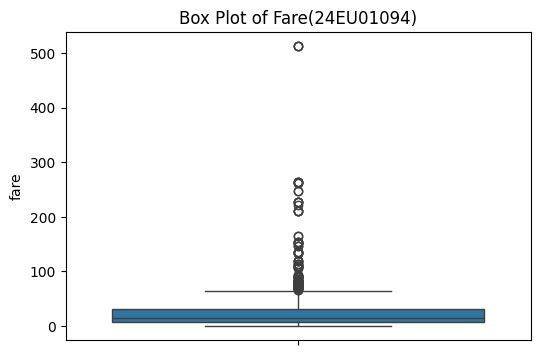

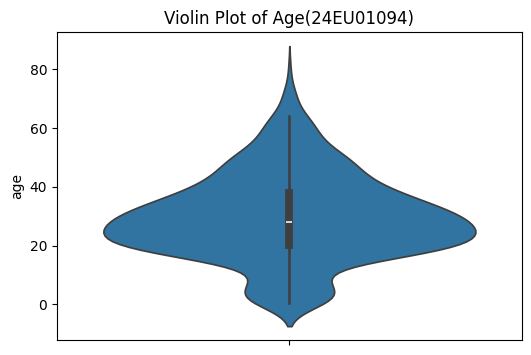

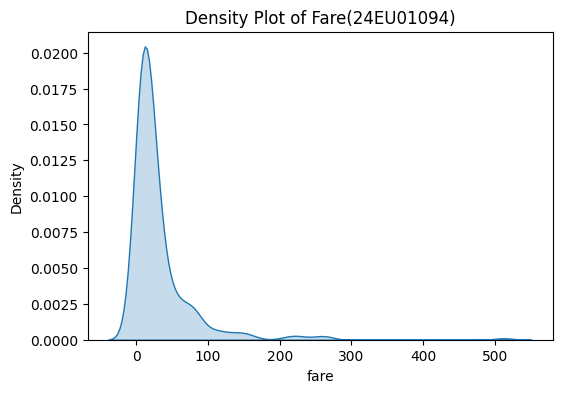

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y="fare", data=df)
plt.title("Box Plot of Fare(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(y="age", data=df)
plt.title("Violin Plot of Age(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(df["fare"], fill=True)
plt.title("Density Plot of Fare(24EU01094)")
plt.show()

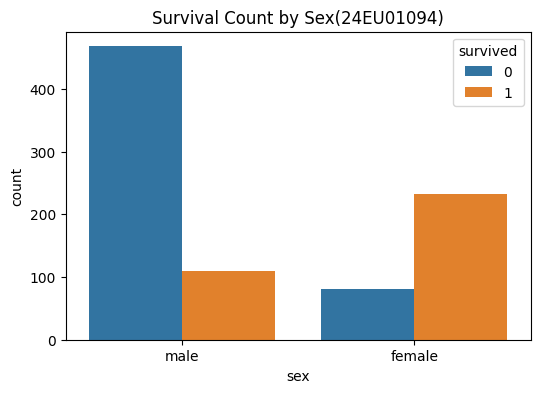

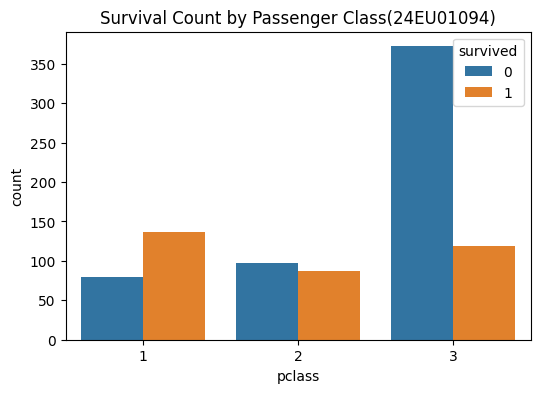

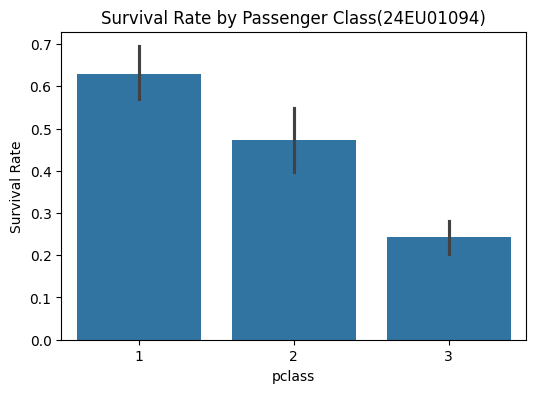

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival Count by Sex(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival Count by Passenger Class(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="pclass", y="survived", data=df)
plt.title("Survival Rate by Passenger Class(24EU01094)")
plt.ylabel("Survival Rate")
plt.show()

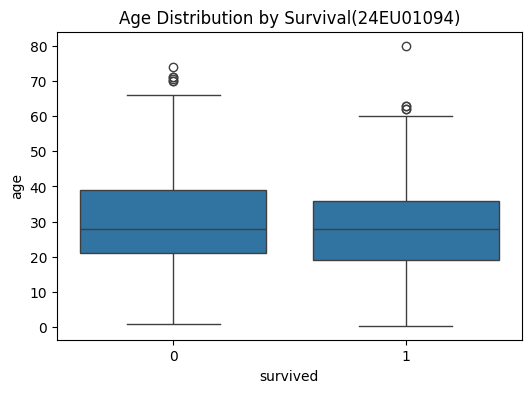

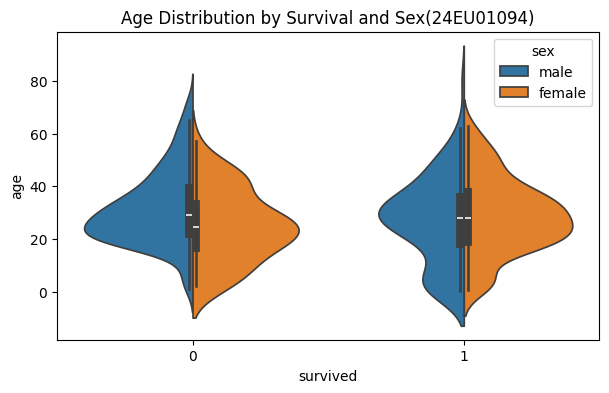

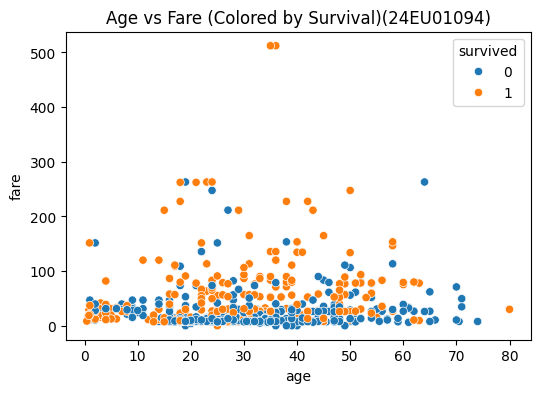

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="survived", y="age", data=df)
plt.title("Age Distribution by Survival(24EU01094)")
plt.show()

plt.figure(figsize=(7,4))
sns.violinplot(x="survived", y="age", hue="sex", data=df, split=True)
plt.title("Age Distribution by Survival and Sex(24EU01094)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="fare", hue="survived", data=df)
plt.title("Age vs Fare (Colored by Survival)(24EU01094)")
plt.show()

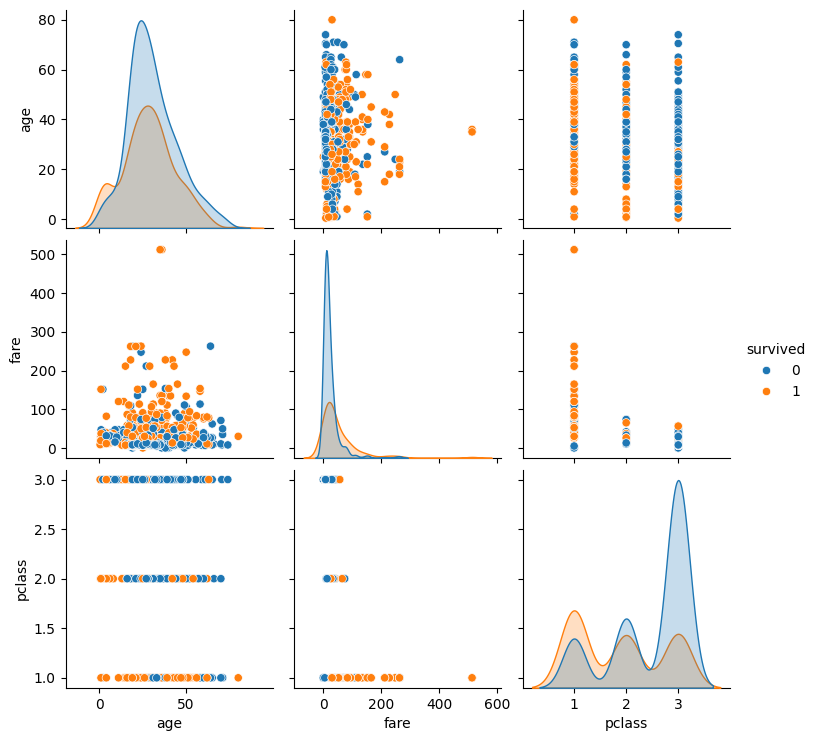

In [ ]:
sns.pairplot(df[["age", "fare", "pclass", "survived"]].dropna(), hue="survived")
plt.show()

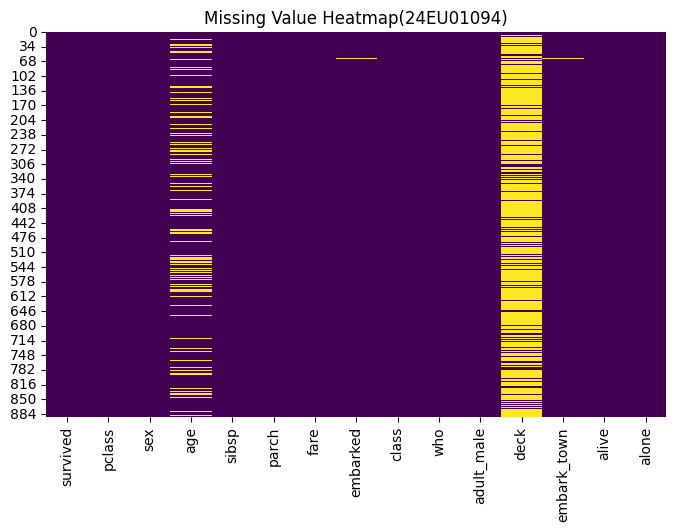

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap(24EU01094)")
plt.show()


            survived    pclass       age     sibsp     parch      fare  \
survived    1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307   
pclass     -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500   
age        -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067   
sibsp      -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651   
parch       0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225   
fare        0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000   
adult_male -0.557080  0.094035  0.280328 -0.253586 -0.349943 -0.182024   
alone      -0.203367  0.135207  0.198270 -0.584471 -0.583398 -0.271832   

            adult_male     alone  
survived     -0.557080 -0.203367  
pclass        0.094035  0.135207  
age           0.280328  0.198270  
sibsp        -0.253586 -0.584471  
parch        -0.349943 -0.583398  
fare         -0.182024 -0.271832  
adult_male    1.000000  0.404744  
alone         0.404744  1.000000  


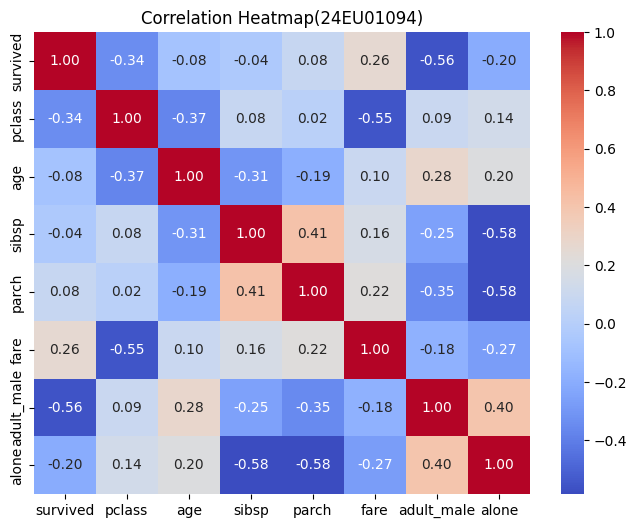

In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap(24EU01094)")
plt.show()

In [ ]:
print("Correlation of Features with Survival:")
print(corr["survived"].sort_values(ascending=False))

Correlation of Features with Survival:
survived      1.000000
fare          0.257307
parch         0.081629
sibsp        -0.035322
age          -0.077221
alone        -0.203367
pclass       -0.338481
adult_male   -0.557080
Name: survived, dtype: float64
